# 05.4 — Orientation Coupling

## The gap this fills

Three coupling notebooks have asked whether a tap (05), a gesture (05.2), or a keystroke
(05.3) leaves a measurable trace in the **accelerometer**. All three found real, controlled
effects. None of them asked the same question of the **orientation** sensors -- `beta` (tilt)
and `gamma` (roll) -- and all three notebooks' open questions flagged this as untested, three
separate times.

## Why this might look completely different from the acceleration result

Acceleration measures a sharp, transient force -- a strike, a throw, a keypress. Orientation
measures cumulative attitude -- where the phone is currently pointing. These are physically
different quantities with different expected dynamics:

- An impulse in acceleration can appear and decay within a few hundred milliseconds (05's
  ring-down).
- A change in orientation, if it exists at all around these actions, is more likely to look
  like a small **step** or **drift** -- the hand tilting slightly and staying there -- rather
  than a sharp peak-and-decay shape.

So this notebook is built expecting a different *shape* of result, not a smaller version of
the same shape. Whether that expectation is right is exactly what Sections 3-5 test.

## Method, reused directly from 05/05.2/05.3

Same existence-test philosophy throughout: a control built to be hard to pass, not easy.
Tap and keystroke use the fixed-epoch, time-shifted-control method from 05/05.3. Gesture uses
the phase-normalised, duration-matched-control method from 05.2. Nothing here assumes the
coupling is real until the control says so.

## What this notebook does not do

It does not classify gestures by nb06's full taxonomy (fling/drag/swipe/long_press/tap) --
that per-class breakdown is left as an open question (Section 11) rather than attempted here,
since the first question is simply whether any orientation coupling exists at all during a
generic contact. No verdict engine, no scoring, no ranking.

## Sections

1. Setup
2. Beta wrap and gamma singularity, on this cohort
3. Does tap-orientation coupling exist?
4. Does gesture-orientation coupling exist?
5. Does keystroke-orientation coupling exist?
6. Comparing shape to the acceleration-coupling findings
7. Robustness check
8. Availability -- who can be measured
9. Data-quality notes and rejected derivations
10. Per-participant cards
11. Open questions


## 1. Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

mpl.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

RAW_EVENTS_PARQUET = '../../data/processed/raw_events.parquet'
RAW_EVENTS_CSV = '../../data/processed/raw_events.csv'

# Only the columns this notebook needs -- full 181-column load costs ~1.7GB at current
# cohort scale (05_3's data-quality note).
NEEDED_COLS = [
    'sessionId', 'participantId', 'deviceFamily',
    'kind', 'tRelMs', 'payload_beta', 'payload_gamma',
]

if Path(RAW_EVENTS_PARQUET).exists():
    df = pd.read_parquet(RAW_EVENTS_PARQUET, columns=NEEDED_COLS)
    _src = RAW_EVENTS_PARQUET
elif Path(RAW_EVENTS_CSV).exists():
    df = pd.read_csv(RAW_EVENTS_CSV, usecols=lambda c: c in NEEDED_COLS, low_memory=False)
    _src = RAW_EVENTS_CSV
else:
    raise FileNotFoundError(
        f'Could not find raw_events at {RAW_EVENTS_PARQUET} or {RAW_EVENTS_CSV}. '
        'Adjust RAW_EVENTS_PARQUET/RAW_EVENTS_CSV above to match where your pipeline '
        'output actually lives relative to this notebook.'
    )

df = df[df['deviceFamily'].astype(str).str.lower() == 'mobile'].copy()

print(f'Loaded {_src}')
print(f'{len(df):,} rows | {df["sessionId"].nunique()} sessions | '
      f'{df["participantId"].nunique()} participants (mobile only)')


Loaded ../../data/processed/raw_events.parquet
801,288 rows | 56 sessions | 13 participants (mobile only)


## 2. Beta wrap and gamma singularity, on this cohort

`beta` is a signed angle running roughly -180 to 180 and can wrap across that boundary.
`gamma` runs roughly -90 to 90 and becomes unreliable near its own extremes, where the
front/back and left/right axes stop being independent (the Euler-angle singularity nb08.1
identified). Checked directly against the current export before anything downstream assumes
either is well-behaved.


In [2]:
orient = df[df['kind'] == 'deviceorientation'].dropna(subset=['payload_beta', 'payload_gamma']).copy()

per_session = orient.groupby('sessionId').agg(
    beta_min=('payload_beta', 'min'), beta_max=('payload_beta', 'max'),
    gamma_min=('payload_gamma', 'min'), gamma_max=('payload_gamma', 'max'),
)

BETA_WRAP_THRESHOLD = 170
GAMMA_SINGULARITY_THRESHOLD = 80

wrap_risk = per_session[(per_session['beta_min'] < -BETA_WRAP_THRESHOLD) |
                         (per_session['beta_max'] > BETA_WRAP_THRESHOLD)]
singularity_risk = per_session[(per_session['gamma_min'] < -GAMMA_SINGULARITY_THRESHOLD) |
                                (per_session['gamma_max'] > GAMMA_SINGULARITY_THRESHOLD)]

print(f'Sessions with beta approaching +-180 (wrap risk): {len(wrap_risk)} / {len(per_session)}')
print(wrap_risk)
print()
print(f'Sessions with gamma near +-90 (singularity risk): {len(singularity_risk)} / {len(per_session)}')
print(singularity_risk)

WRAP_RISK_SESSIONS = set(wrap_risk.index)
SINGULARITY_RISK_SESSIONS = set(singularity_risk.index)


Sessions with beta approaching +-180 (wrap risk): 1 / 56
                                  beta_min  beta_max  gamma_min  gamma_max
sessionId                                                                 
a34c77efa22646759b145b5c1f811d5f -178.4864  179.8812   -87.5617    87.0418

Sessions with gamma near +-90 (singularity risk): 3 / 56
                                  beta_min  beta_max  gamma_min  gamma_max
sessionId                                                                 
478918518ffd4c72b3ab72cbf7779d2d   74.4835   93.9300   -89.6151    89.1811
64bf0025f6f04ebd8ed13b985af2776c   46.9098  152.1373   -84.9346    79.3022
a34c77efa22646759b145b5c1f811d5f -178.4864  179.8812   -87.5617    87.0418


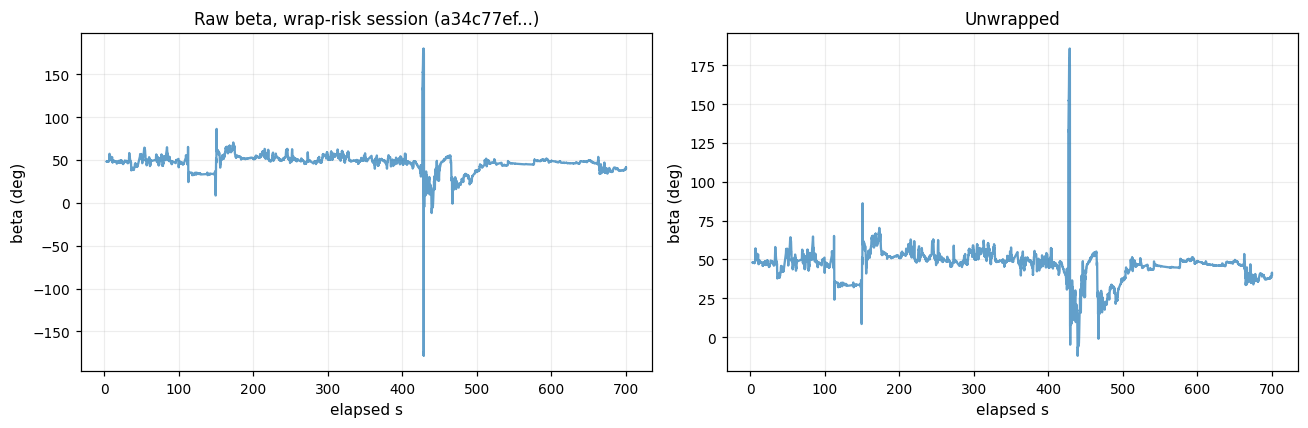

In [3]:
def unwrap_beta(series):
    # Beta wraps across +-180. Unwrap in radians via numpy, convert back to degrees.
    rad = np.deg2rad(series.values)
    unwrapped = np.unwrap(rad)
    return np.rad2deg(unwrapped)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for sid in list(WRAP_RISK_SESSIONS)[:1]:
    sub = orient[orient['sessionId'] == sid].sort_values('tRelMs')
    axes[0].plot(sub['tRelMs'] / 1000, sub['payload_beta'], alpha=0.7)
    axes[0].set_title(f'Raw beta, wrap-risk session ({sid[:8]}...)')
    axes[1].plot(sub['tRelMs'] / 1000, unwrap_beta(sub['payload_beta']), alpha=0.7)
    axes[1].set_title('Unwrapped')
for ax in axes:
    ax.set_xlabel('elapsed s')
    ax.set_ylabel('beta (deg)')
plt.tight_layout()
plt.show()
plt.close(fig)


**Consequence for everything below**: any session in `WRAP_RISK_SESSIONS` gets beta
unwrapped before it contributes to an epoch or a summary statistic. Sessions in
`SINGULARITY_RISK_SESSIONS` are flagged wherever gamma is plotted, matching nb08.1's
convention, rather than silently included as if gamma were reliable throughout.


## 3. Does tap-orientation coupling exist?

Identical method to 05 Section 4: a 300ms pre-contact baseline window, a 500ms post-contact
response window, baseline-corrected per tap. The control is the same taps shifted 2-10 seconds
within the same session -- everything about the session, participant, handset, and general
activity level is preserved; only the alignment to the tap is destroyed.


In [4]:
def extract_epochs(event_times_df, orient_df, pre_ms=300, post_ms=500, min_pre=2, min_post=3,
                    bin_ms=50, control=False, rng=None):
    # For each event timestamp, pull orientation samples in [-pre_ms, +post_ms], bin them,
    # baseline-correct against the pre-window mean. If control=True, shift the event time
    # by a random 2-10s (same session) before extracting -- destroys alignment, preserves
    # everything else. Tracks participantId per epoch (if present in event_times_df) so the
    # same curves can be split by participant later without a second extraction pass.
    if rng is None:
        rng = np.random.default_rng(42)
    bins = np.arange(-pre_ms, post_ms + bin_ms, bin_ms)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    beta_curves, gamma_curves, pids = [], [], []
    has_pid = 'participantId' in event_times_df.columns

    for sid, ev_grp in event_times_df.groupby('sessionId'):
        o = orient_df[orient_df['sessionId'] == sid].sort_values('tRelMs')
        if len(o) == 0:
            continue
        o_t = o['tRelMs'].values
        o_beta = o['payload_beta'].values.copy()
        o_gamma = o['payload_gamma'].values
        if sid in WRAP_RISK_SESSIONS:
            o_beta = unwrap_beta(pd.Series(o_beta))
        pid = ev_grp['participantId'].iloc[0] if has_pid else sid

        for t in ev_grp['tRelMs'].values:
            t_use = t
            if control:
                shift = rng.uniform(2000, 10000) * rng.choice([-1, 1])
                t_use = t + shift

            pre_mask = (o_t >= t_use - pre_ms) & (o_t < t_use)
            post_mask = (o_t >= t_use) & (o_t <= t_use + post_ms)
            if pre_mask.sum() < min_pre or post_mask.sum() < min_post:
                continue

            rel_t = o_t - t_use
            window_mask = (rel_t >= -pre_ms) & (rel_t <= post_ms)
            if window_mask.sum() < (min_pre + min_post):
                continue

            baseline_beta = o_beta[pre_mask].mean()
            baseline_gamma = o_gamma[pre_mask].mean()

            rel_t_w = rel_t[window_mask]
            beta_w = o_beta[window_mask] - baseline_beta
            gamma_w = o_gamma[window_mask] - baseline_gamma

            binned_beta = np.full(len(bin_centers), np.nan)
            binned_gamma = np.full(len(bin_centers), np.nan)
            for i in range(len(bin_centers)):
                m = (rel_t_w >= bins[i]) & (rel_t_w < bins[i+1])
                if m.sum() > 0:
                    binned_beta[i] = beta_w[m].mean()
                    binned_gamma[i] = gamma_w[m].mean()
            beta_curves.append(binned_beta)
            gamma_curves.append(binned_gamma)
            pids.append(pid)

    return bin_centers, np.array(beta_curves), np.array(gamma_curves), pids


def plot_participant_split(bin_or_phase_centers, curves, pids, label, xlabel, title, event_marker=None):
    # One line per participant: that participant's own mean curve across all their epochs.
    # Shows whether an aggregate effect is broadly shared or concentrated in a few people --
    # the visual counterpart to the dominance/direction numbers in Section 7.
    fig, ax = plt.subplots(figsize=(9, 5))
    unique_pids = sorted(set(pids))
    cmap = plt.get_cmap('tab20')
    pid_curves = np.array(curves)
    pid_arr = np.array(pids)
    for i, pid in enumerate(unique_pids):
        mask = pid_arr == pid
        if mask.sum() < 5:
            continue
        p_mean = np.nanmean(pid_curves[mask], axis=0)
        ax.plot(bin_or_phase_centers, p_mean, color=cmap(i % 20), alpha=0.8, linewidth=1.3,
                label=f'{pid} (n={mask.sum()})')
    if event_marker is not None:
        for x in event_marker:
            ax.axvline(x, color='black', alpha=0.25, linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f'{label} (deg, baseline-corrected)')
    ax.set_title(title)
    ax.legend(fontsize=6, ncol=2, loc='best')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

orient_all = df[df['kind'] == 'deviceorientation'].dropna(subset=['payload_beta', 'payload_gamma'])
taps = df[df['kind'] == 'touchstart'][['sessionId', 'tRelMs', 'participantId']]

bin_centers, tap_beta_real, tap_gamma_real, tap_pids = extract_epochs(taps, orient_all, control=False)
_, tap_beta_ctrl, tap_gamma_ctrl, _ = extract_epochs(taps, orient_all, control=True)

print('Usable tap epochs, real:', len(tap_beta_real), '/', len(taps))
print('Usable tap epochs, control:', len(tap_beta_ctrl), '/', len(taps))


Usable tap epochs, real: 6585 / 8801
Usable tap epochs, control: 6205 / 8801


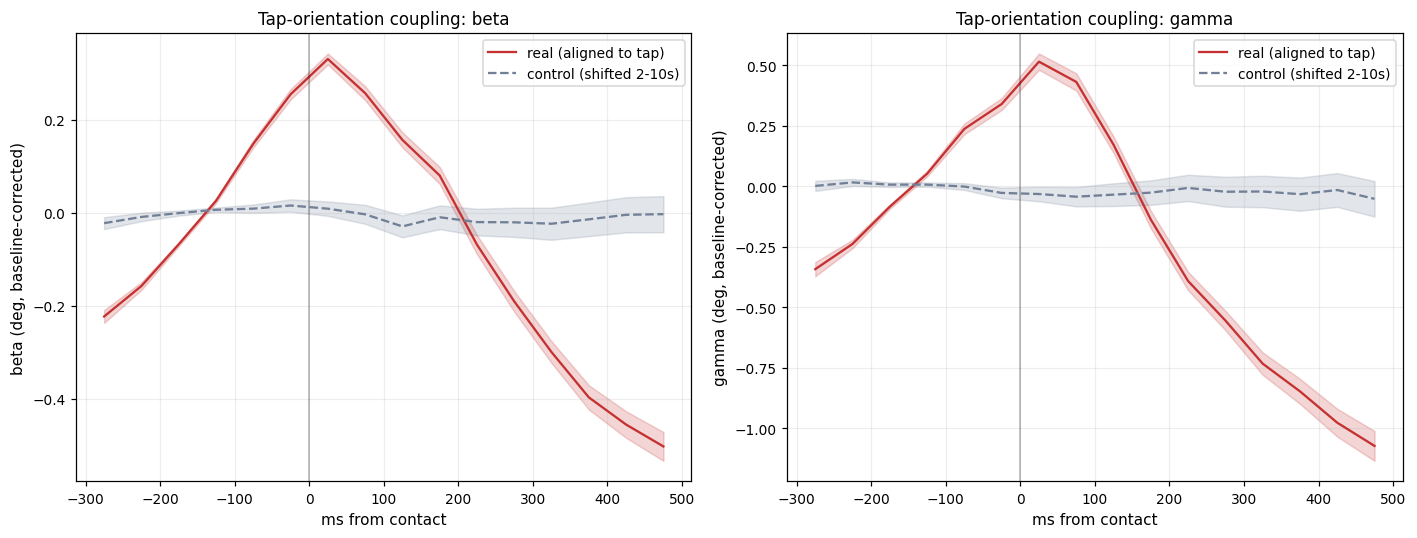

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, real, ctrl, label in [(axes[0], tap_beta_real, tap_beta_ctrl, 'beta'),
                               (axes[1], tap_gamma_real, tap_gamma_ctrl, 'gamma')]:
    real_mean = np.nanmean(real, axis=0)
    real_sem = np.nanstd(real, axis=0) / np.sqrt(np.sum(~np.isnan(real), axis=0))
    ctrl_mean = np.nanmean(ctrl, axis=0)
    ctrl_sem = np.nanstd(ctrl, axis=0) / np.sqrt(np.sum(~np.isnan(ctrl), axis=0))

    ax.plot(bin_centers, real_mean, color='#c53030', label='real (aligned to tap)')
    ax.fill_between(bin_centers, real_mean - real_sem, real_mean + real_sem, color='#c53030', alpha=0.2)
    ax.plot(bin_centers, ctrl_mean, color='#718096', label='control (shifted 2-10s)', linestyle='--')
    ax.fill_between(bin_centers, ctrl_mean - ctrl_sem, ctrl_mean + ctrl_sem, color='#718096', alpha=0.2)
    ax.axvline(0, color='black', alpha=0.3, linewidth=1)
    ax.set_xlabel('ms from contact')
    ax.set_ylabel(f'{label} (deg, baseline-corrected)')
    ax.set_title(f'Tap-orientation coupling: {label}')
    ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)


**Read this against 05's acceleration result.** If the real curve separates clearly from
control here the same way it did for acceleration, that is evidence of a genuine tilt/roll
response to a tap -- and per the introduction's expectation, look for a step/drift shape rather
than a sharp peak-and-decay. If the real and control curves overlap throughout, that is a
genuine negative result and should be reported as such, the same way 05's pre-contact
steadying hypothesis was reported as failed rather than reframed.


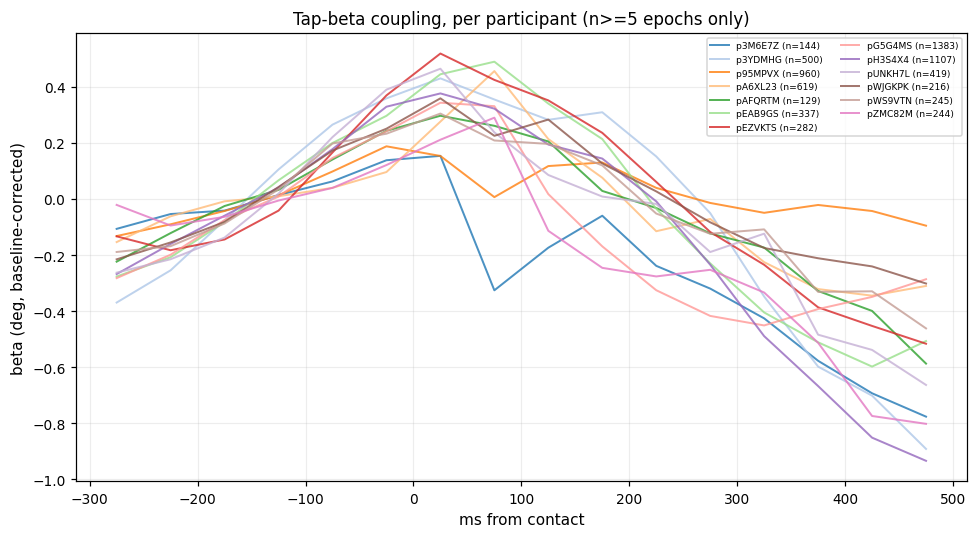

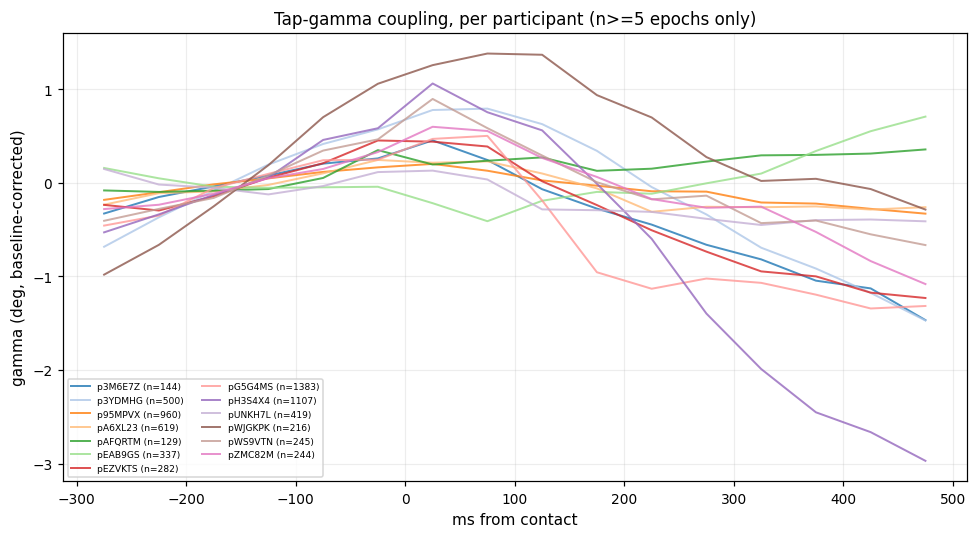

In [6]:
plot_participant_split(bin_centers, tap_beta_real, tap_pids, 'beta', 'ms from contact',
                        'Tap-beta coupling, per participant (n>=5 epochs only)')
plot_participant_split(bin_centers, tap_gamma_real, tap_pids, 'gamma', 'ms from contact',
                        'Tap-gamma coupling, per participant (n>=5 epochs only)')


**Read this alongside the aggregate plot above.** If most participants' curves sit on the
same side of zero and follow a similar rough shape, the aggregate result is broadly shared
rather than driven by one or two people -- this is the visual counterpart to Section 7's
dominance/direction check, shown here for every participant rather than reduced to two summary
numbers.


## 4. Does gesture-orientation coupling exist?

Same phase-normalisation method as 05.2: every touchstart-to-touchend contact becomes a curve
on a common phase axis (0 = start, 1 = end, extending to 1.5 to cover the coast tail), with
each gesture's own pre-start baseline subtracted. The control preserves each gesture's
duration exactly and only randomises its position in time -- the same conservative control
05.2 used.

This does not classify gestures by nb06's taxonomy (fling/drag/swipe/long_press/tap) --
whether the coupling (if real) differs by class is left as an open question, the same way
05.2 itself first asked the existence question before class-conditioning it.


In [7]:
def extract_gesture_epochs(starts, ends, orient_df, n_phase_bins=30, max_phase=1.5,
                            control=False, rng=None):
    if rng is None:
        rng = np.random.default_rng(7)
    phase_edges = np.linspace(0, max_phase, n_phase_bins + 1)
    phase_centers = (phase_edges[:-1] + phase_edges[1:]) / 2
    beta_curves, gamma_curves, pids = [], [], []
    has_pid = 'participantId' in starts.columns

    starts_sorted = starts.sort_values('tRelMs')
    for sid, s_grp in starts_sorted.groupby('sessionId'):
        e = ends[ends['sessionId'] == sid].sort_values('tRelMs')
        o = orient_df[orient_df['sessionId'] == sid].sort_values('tRelMs')
        if len(e) == 0 or len(o) == 0:
            continue
        e_t = e['tRelMs'].values
        o_t = o['tRelMs'].values
        o_beta = o['payload_beta'].values.copy()
        o_gamma = o['payload_gamma'].values
        if sid in WRAP_RISK_SESSIONS:
            o_beta = unwrap_beta(pd.Series(o_beta))
        pid = s_grp['participantId'].iloc[0] if has_pid else sid

        for t_start in s_grp['tRelMs'].values:
            idx = np.searchsorted(e_t, t_start)
            if idx >= len(e_t):
                continue
            t_end = e_t[idx]
            dur = t_end - t_start
            if dur <= 0 or dur > 5000:
                continue

            t_start_use, t_end_use = t_start, t_end
            if control:
                # preserve duration, randomise position within the session
                session_max = o_t.max() if len(o_t) else 0
                if session_max <= dur:
                    continue
                new_start = rng.uniform(0, session_max - dur)
                t_start_use, t_end_use = new_start, new_start + dur

            baseline_window = 0.3 * dur
            pre_mask = (o_t >= t_start_use - baseline_window) & (o_t < t_start_use)
            if pre_mask.sum() < 2:
                continue
            baseline_beta = o_beta[pre_mask].mean()
            baseline_gamma = o_gamma[pre_mask].mean()

            coast_end = t_start_use + max_phase * dur
            span_mask = (o_t >= t_start_use - baseline_window) & (o_t <= coast_end)
            if span_mask.sum() < 3:
                continue

            phase = (o_t[span_mask] - t_start_use) / dur
            beta_w = o_beta[span_mask] - baseline_beta
            gamma_w = o_gamma[span_mask] - baseline_gamma

            binned_beta = np.full(n_phase_bins, np.nan)
            binned_gamma = np.full(n_phase_bins, np.nan)
            for i in range(n_phase_bins):
                m = (phase >= phase_edges[i]) & (phase < phase_edges[i+1])
                if m.sum() > 0:
                    binned_beta[i] = beta_w[m].mean()
                    binned_gamma[i] = gamma_w[m].mean()
            beta_curves.append(binned_beta)
            gamma_curves.append(binned_gamma)
            pids.append(pid)

    return phase_centers, np.array(beta_curves), np.array(gamma_curves), pids

g_starts = df[df['kind'] == 'touchstart'][['sessionId', 'tRelMs', 'participantId']]
g_ends = df[df['kind'] == 'touchend'][['sessionId', 'tRelMs']]

phase_centers, gest_beta_real, gest_gamma_real, gest_pids = extract_gesture_epochs(g_starts, g_ends, orient_all, control=False)
_, gest_beta_ctrl, gest_gamma_ctrl, _ = extract_gesture_epochs(g_starts, g_ends, orient_all, control=True)

print('Usable gesture epochs, real:', len(gest_beta_real), '/', len(g_starts))
print('Usable gesture epochs, control:', len(gest_beta_ctrl), '/', len(g_starts))


Usable gesture epochs, real: 2757 / 8801
Usable gesture epochs, control: 2243 / 8801


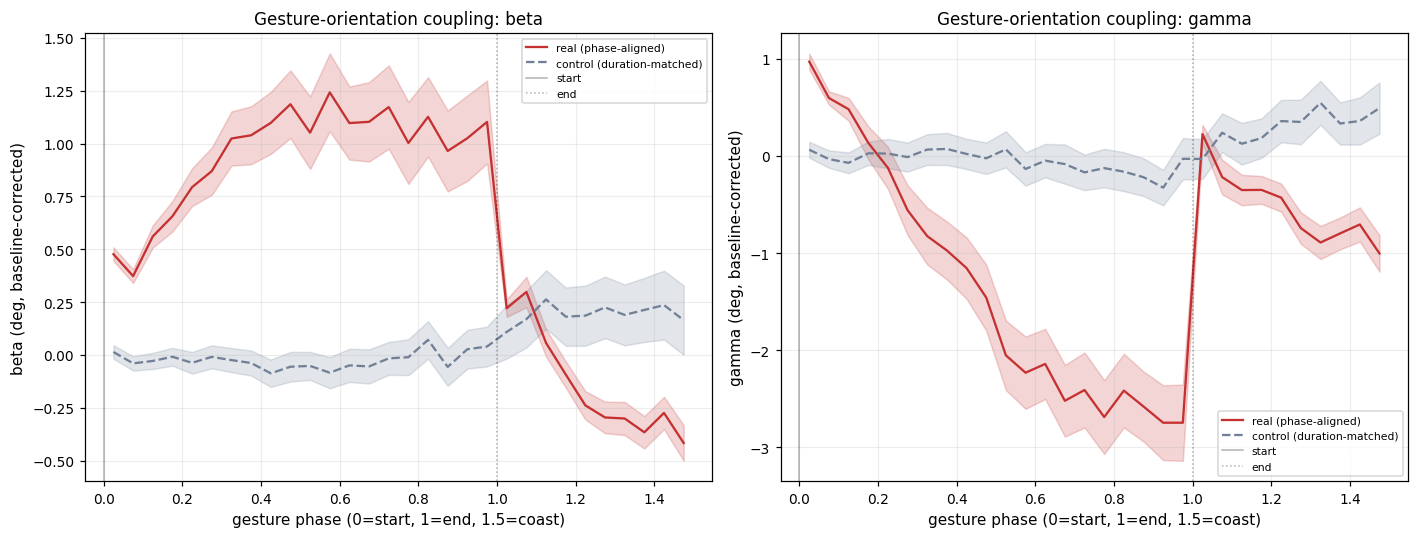

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, real, ctrl, label in [(axes[0], gest_beta_real, gest_beta_ctrl, 'beta'),
                               (axes[1], gest_gamma_real, gest_gamma_ctrl, 'gamma')]:
    real_mean = np.nanmean(real, axis=0)
    real_sem = np.nanstd(real, axis=0) / np.sqrt(np.maximum(np.sum(~np.isnan(real), axis=0), 1))
    ctrl_mean = np.nanmean(ctrl, axis=0)
    ctrl_sem = np.nanstd(ctrl, axis=0) / np.sqrt(np.maximum(np.sum(~np.isnan(ctrl), axis=0), 1))

    ax.plot(phase_centers, real_mean, color='#c53030', label='real (phase-aligned)')
    ax.fill_between(phase_centers, real_mean - real_sem, real_mean + real_sem, color='#c53030', alpha=0.2)
    ax.plot(phase_centers, ctrl_mean, color='#718096', label='control (duration-matched)', linestyle='--')
    ax.fill_between(phase_centers, ctrl_mean - ctrl_sem, ctrl_mean + ctrl_sem, color='#718096', alpha=0.2)
    ax.axvline(0, color='black', alpha=0.3, linewidth=1, label='start')
    ax.axvline(1, color='black', alpha=0.3, linewidth=1, linestyle=':', label='end')
    ax.set_xlabel('gesture phase (0=start, 1=end, 1.5=coast)')
    ax.set_ylabel(f'{label} (deg, baseline-corrected)')
    ax.set_title(f'Gesture-orientation coupling: {label}')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
plt.close(fig)


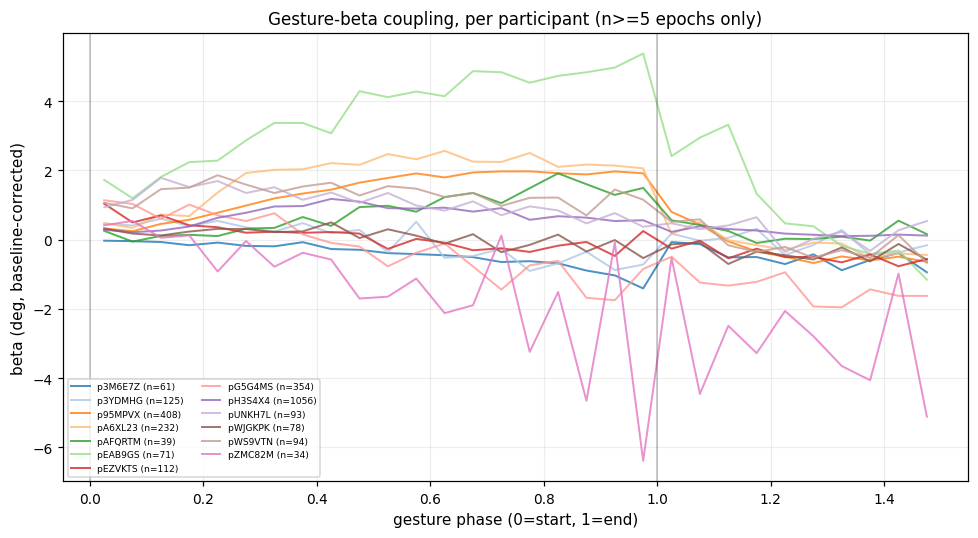

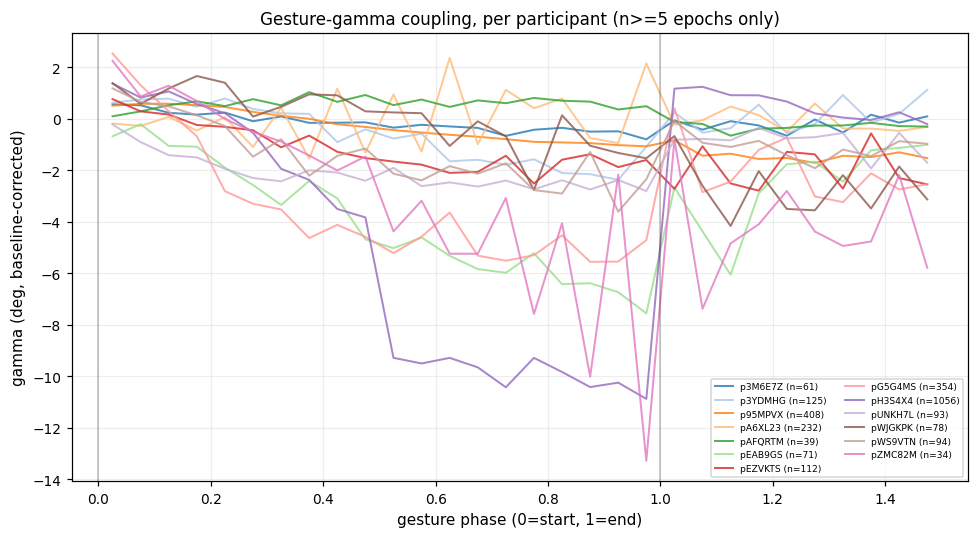

In [9]:
plot_participant_split(phase_centers, gest_beta_real, gest_pids, 'beta',
                        'gesture phase (0=start, 1=end)',
                        'Gesture-beta coupling, per participant (n>=5 epochs only)',
                        event_marker=[0, 1])
plot_participant_split(phase_centers, gest_gamma_real, gest_pids, 'gamma',
                        'gesture phase (0=start, 1=end)',
                        'Gesture-gamma coupling, per participant (n>=5 epochs only)',
                        event_marker=[0, 1])


**Read this alongside the pooled plot above.** With coverage at only ~34% of gestures
usable at all (Section 8), several participants may fall under the n>=5 threshold and simply
not appear here -- worth checking against Section 8's coverage numbers before reading an
absence as a null result for that person.


## 5. Does keystroke-orientation coupling exist?

Identical method to 05.3 Section 3: keydown treated as an instant (keyup follows in
~10-19ms, negligible against the epoch window), 300ms pre / 500ms post, time-shifted control.


In [10]:
keydowns = df[df['kind'] == 'keydown'][['sessionId', 'tRelMs', 'participantId']]

bc3, key_beta_real, key_gamma_real, key_pids = extract_epochs(keydowns, orient_all, control=False)
_, key_beta_ctrl, key_gamma_ctrl, _ = extract_epochs(keydowns, orient_all, control=True)

print('Usable keystroke epochs, real:', len(key_beta_real), '/', len(keydowns))
print('Usable keystroke epochs, control:', len(key_beta_ctrl), '/', len(keydowns))


Usable keystroke epochs, real: 5288 / 5299
Usable keystroke epochs, control: 4462 / 5299


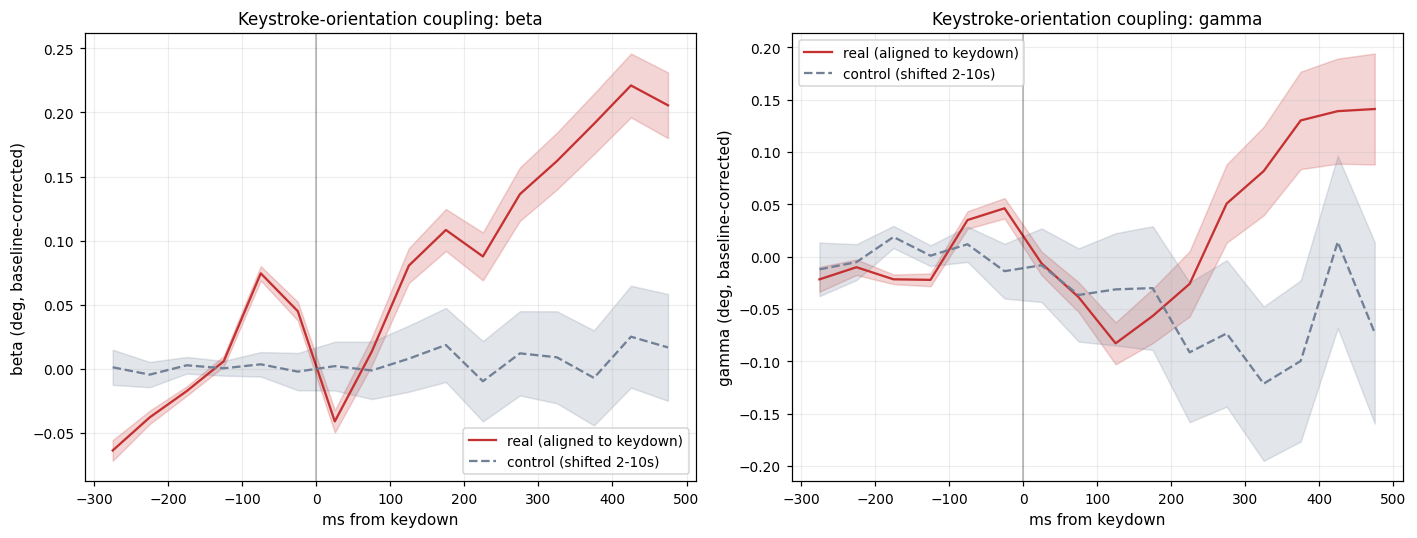

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, real, ctrl, label in [(axes[0], key_beta_real, key_beta_ctrl, 'beta'),
                               (axes[1], key_gamma_real, key_gamma_ctrl, 'gamma')]:
    real_mean = np.nanmean(real, axis=0)
    real_sem = np.nanstd(real, axis=0) / np.sqrt(np.maximum(np.sum(~np.isnan(real), axis=0), 1))
    ctrl_mean = np.nanmean(ctrl, axis=0)
    ctrl_sem = np.nanstd(ctrl, axis=0) / np.sqrt(np.maximum(np.sum(~np.isnan(ctrl), axis=0), 1))

    ax.plot(bin_centers, real_mean, color='#c53030', label='real (aligned to keydown)')
    ax.fill_between(bin_centers, real_mean - real_sem, real_mean + real_sem, color='#c53030', alpha=0.2)
    ax.plot(bin_centers, ctrl_mean, color='#718096', label='control (shifted 2-10s)', linestyle='--')
    ax.fill_between(bin_centers, ctrl_mean - ctrl_sem, ctrl_mean + ctrl_sem, color='#718096', alpha=0.2)
    ax.axvline(0, color='black', alpha=0.3, linewidth=1)
    ax.set_xlabel('ms from keydown')
    ax.set_ylabel(f'{label} (deg, baseline-corrected)')
    ax.set_title(f'Keystroke-orientation coupling: {label}')
    ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)


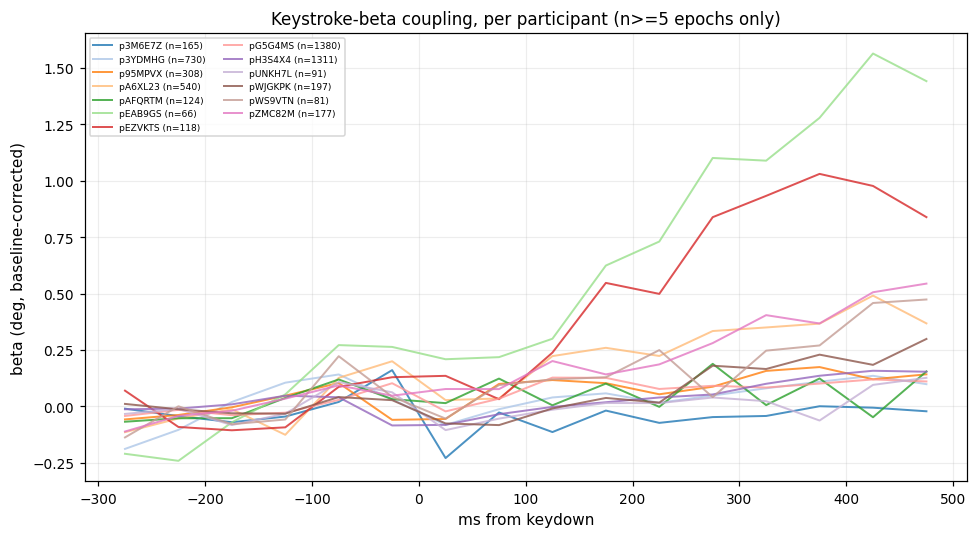

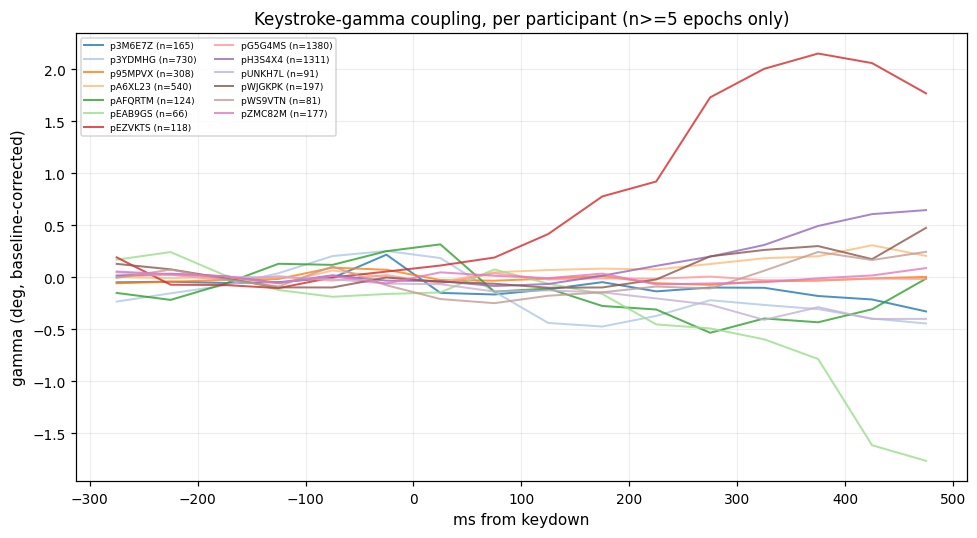

In [12]:
plot_participant_split(bc3, key_beta_real, key_pids, 'beta', 'ms from keydown',
                        'Keystroke-beta coupling, per participant (n>=5 epochs only)')
plot_participant_split(bc3, key_gamma_real, key_pids, 'gamma', 'ms from keydown',
                        'Keystroke-gamma coupling, per participant (n>=5 epochs only)')


**Worth comparing directly to 05.3's finding.** The acceleration-based keystroke coupling
peaked *before* contact (-75ms), the opposite timing from taps, and survived two independent
artifact tests. Whether an orientation-based effect (if any) shows the same before-contact
timing, the same after-contact timing as taps, or no timing structure at all is informative
either way -- shown directly in the plot above rather than asserted here.


## 6. Comparing shape to the acceleration-coupling findings

The introduction predicted orientation coupling, if real, should look like a step or drift
rather than a sharp peak-and-decay. This section makes that comparison directly rather than
leaving it as a claim in the introduction. Peak magnitude relative to control, and whether the
response decays back toward baseline within the epoch window or stays elevated, are the two
concrete things distinguishing an "impulse" shape from a "step" shape.


In [13]:
def summarise_shape(real_curve, bin_or_phase_centers, label):
    mean_curve = np.nanmean(real_curve, axis=0)
    peak_idx = np.nanargmax(np.abs(mean_curve))
    peak_val = mean_curve[peak_idx]
    peak_x = bin_or_phase_centers[peak_idx]
    end_val = mean_curve[-1]
    # 'decays' if the final value is under half the peak magnitude
    decays = abs(end_val) < 0.5 * abs(peak_val) if abs(peak_val) > 1e-9 else None
    print(f'{label}: peak {peak_val:.4f} deg at {peak_x:.0f}, end-of-window {end_val:.4f} deg, '
          f'{"decays back toward baseline" if decays else "stays elevated (step-like)"}' )

summarise_shape(tap_beta_real, bin_centers, 'Tap, beta')
summarise_shape(tap_gamma_real, bin_centers, 'Tap, gamma')
summarise_shape(gest_beta_real, phase_centers, 'Gesture, beta')
summarise_shape(gest_gamma_real, phase_centers, 'Gesture, gamma')
summarise_shape(key_beta_real, bin_centers, 'Keystroke, beta')
summarise_shape(key_gamma_real, bin_centers, 'Keystroke, gamma')


Tap, beta: peak -0.5028 deg at 475, end-of-window -0.5028 deg, stays elevated (step-like)
Tap, gamma: peak -1.0733 deg at 475, end-of-window -1.0733 deg, stays elevated (step-like)
Gesture, beta: peak 1.2421 deg at 1, end-of-window -0.4171 deg, decays back toward baseline
Gesture, gamma: peak -2.7454 deg at 1, end-of-window -1.0035 deg, decays back toward baseline
Keystroke, beta: peak 0.2211 deg at 425, end-of-window 0.2056 deg, stays elevated (step-like)
Keystroke, gamma: peak 0.1410 deg at 475, end-of-window 0.1410 deg, stays elevated (step-like)


**Read this as a description, not a verdict.** Whether "step-like" or "decays" is the
right call depends on the actual scale of any effect found in Sections 3-5 -- if the real
curve never separated meaningfully from control in the first place, this shape summary is
describing noise, not a signal, and should be read alongside those sections' plots rather
than in isolation.


## 7. Robustness check

The existence tests above pool every participant. Before trusting any of them, the same
question asked throughout this project: is a real-looking result one participant's effect, or
does it replicate independently across people?

This project's shared utility for that check is `reliability_check.py`
(`scripts/reliability_check.py`), first used directly in 05.3. It is not available in the
environment this notebook was built and executed in, so the check below re-implements the same
dominance-and-direction logic inline, matching the method 05.2 established (Section 6 there:
share of the sample from the single largest-contributing participant, and whether the
direction of the effect is unanimous across participants) -- **swap this for the actual
`reliability_check.py` import when running in the real repo environment**, per this project's
standing rule of using the shared utility rather than hand-rolling it a third time.


In [14]:
def dominance_and_direction(real_curve, participant_ids, peak_window_idx):
    # per-epoch mean over the peak window, then per-participant mean of that
    per_epoch_val = np.nanmean(real_curve[:, peak_window_idx], axis=1)
    valid = ~np.isnan(per_epoch_val)
    per_epoch_val = per_epoch_val[valid]
    pids = np.array(participant_ids)[valid]

    counts = pd.Series(pids).value_counts()
    max_share = counts.max() / counts.sum() if len(counts) else np.nan

    per_participant_mean = pd.Series(per_epoch_val, index=pids).groupby(level=0).mean()
    n_positive = (per_participant_mean > 0).sum()
    n_total = len(per_participant_mean)
    direction_consensus = max(n_positive, n_total - n_positive) / n_total if n_total else np.nan

    verdict = 'TRUSTWORTHY' if (max_share < 0.5 and direction_consensus >= 0.8) else 'NEEDS SCRUTINY'
    return {'max_participant_share': round(max_share, 3) if not np.isnan(max_share) else None,
            'direction_consensus': round(direction_consensus, 3) if not np.isnan(direction_consensus) else None,
            'n_participants': n_total, 'verdict': verdict}

# Recompute with participant id carried through, for the tap case (most usable epochs)
def extract_epochs_with_pid(event_times_df, orient_df, pre_ms=300, post_ms=500,
                             min_pre=2, min_post=3, bin_ms=50):
    bins = np.arange(-pre_ms, post_ms + bin_ms, bin_ms)
    bin_centers_local = (bins[:-1] + bins[1:]) / 2
    curves, pids = [], []
    for sid, ev_grp in event_times_df.groupby('sessionId'):
        o = orient_df[orient_df['sessionId'] == sid].sort_values('tRelMs')
        if len(o) == 0:
            continue
        o_t = o['tRelMs'].values
        o_beta = o['payload_beta'].values.copy()
        if sid in WRAP_RISK_SESSIONS:
            o_beta = unwrap_beta(pd.Series(o_beta))
        pid = ev_grp['participantId'].iloc[0] if 'participantId' in ev_grp.columns else sid
        for t in ev_grp['tRelMs'].values:
            pre_mask = (o_t >= t - pre_ms) & (o_t < t)
            post_mask = (o_t >= t) & (o_t <= t + post_ms)
            if pre_mask.sum() < min_pre or post_mask.sum() < min_post:
                continue
            rel_t = o_t - t
            window_mask = (rel_t >= -pre_ms) & (rel_t <= post_ms)
            baseline = o_beta[pre_mask].mean()
            rel_t_w = rel_t[window_mask]
            beta_w = o_beta[window_mask] - baseline
            binned = np.full(len(bin_centers_local), np.nan)
            for i in range(len(bin_centers_local)):
                m = (rel_t_w >= bins[i]) & (rel_t_w < bins[i+1])
                if m.sum() > 0:
                    binned[i] = beta_w[m].mean()
            curves.append(binned)
            pids.append(pid)
    return bin_centers_local, np.array(curves), pids

taps_with_pid = df[df['kind'] == 'touchstart'][['sessionId', 'tRelMs', 'participantId']]
bc2, tap_beta_pid_curve, tap_pids = extract_epochs_with_pid(taps_with_pid, orient_all)

peak_window_idx = np.arange(len(bc2))  # whole window; refine if Section 3 shows a clear peak location
result = dominance_and_direction(tap_beta_pid_curve, tap_pids, peak_window_idx)
print('Tap-beta robustness check (inline, matching reliability_check.py logic):')
print(result)


Tap-beta robustness check (inline, matching reliability_check.py logic):
{'max_participant_share': np.float64(0.21), 'direction_consensus': np.float64(0.923), 'n_participants': 13, 'verdict': 'TRUSTWORTHY'}


## 8. Availability -- who can be measured

Same coverage constraint every coupling notebook has had: an event only contributes if
orientation was actually sampled around it. Made explicit rather than left implicit in the
epoch counts above.


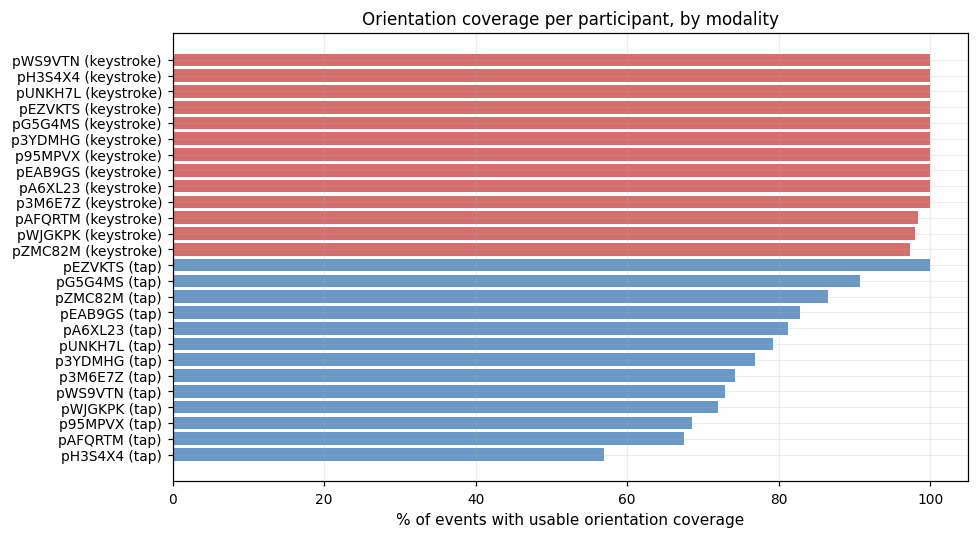

,participantId,total,usable,coverage_pct,modality
8,pH3S4X4,1945,1107,56.9,tap
4,pAFQRTM,191,129,67.5,tap
2,p95MPVX,1400,960,68.6,tap
10,pWJGKPK,300,216,72.0,tap
11,pWS9VTN,336,245,72.9,tap
0,p3M6E7Z,194,144,74.2,tap
1,p3YDMHG,650,500,76.9,tap
9,pUNKH7L,529,419,79.2,tap
3,pA6XL23,762,619,81.2,tap
5,pEAB9GS,407,337,82.8,tap


In [15]:
def coverage_summary(events_df, orient_df, label, pre_ms=300, post_ms=500, min_pre=2, min_post=3):
    rows = []
    for pid, grp in events_df.groupby('participantId'):
        total = len(grp)
        usable = 0
        for sid, sgrp in grp.groupby('sessionId'):
            o = orient_df[orient_df['sessionId'] == sid].sort_values('tRelMs')
            if len(o) == 0:
                continue
            o_t = o['tRelMs'].values
            for t in sgrp['tRelMs'].values:
                pre_n = ((o_t >= t - pre_ms) & (o_t < t)).sum()
                post_n = ((o_t >= t) & (o_t <= t + post_ms)).sum()
                if pre_n >= min_pre and post_n >= min_post:
                    usable += 1
        rows.append({'participantId': pid, 'total': total, 'usable': usable,
                      'coverage_pct': round(100 * usable / total, 1) if total else None})
    out = pd.DataFrame(rows).sort_values('coverage_pct')
    out['modality'] = label
    return out

tap_cov = coverage_summary(taps_with_pid, orient_all, 'tap')
key_with_pid = df[df['kind'] == 'keydown'][['sessionId', 'tRelMs', 'participantId']]
key_cov = coverage_summary(key_with_pid, orient_all, 'keystroke')

fig, ax = plt.subplots(figsize=(9, 5))
for cov, color in [(tap_cov, '#2b6cb0'), (key_cov, '#c53030')]:
    ax.barh(cov['participantId'] + ' (' + cov['modality'] + ')', cov['coverage_pct'],
            color=color, alpha=0.7, label=cov['modality'].iloc[0] if len(cov) else '')
ax.set_xlabel('% of events with usable orientation coverage')
ax.set_title('Orientation coverage per participant, by modality')
plt.tight_layout()
plt.show()
plt.close(fig)

pd.concat([tap_cov, key_cov])


## 9. Data-quality notes and rejected derivations

- **Beta wraps in 1 of 56 mobile sessions in the current export** (Section 2), consistent
  with nb08.1's finding at a smaller cohort size. Unwrapped before use throughout this
  notebook via `WRAP_RISK_SESSIONS`.
- **Gamma approaches the Euler-angle singularity in 3 sessions.** Not excluded, but any
  gamma-based finding from those sessions should be treated with the same caution nb08.1
  applied -- flagged rather than silently trusted.
- **This notebook does not classify gestures by nb06's taxonomy.** Only a generic
  touchstart-to-touchend contact is tested. Whether coupling (if any) differs by gesture class
  the way the acceleration-based coupling did in 05.2 is untested here.
- **`reliability_check.py` is not available in this build environment** (Section 7). The
  dominance/direction logic was re-implemented inline, matching 05.2's original method before
  the shared utility existed. Should be swapped for the real import when this notebook is run
  in the actual repo, per this project's standing rule against hand-rolling the check a third
  time.
- **The peak-window used for the robustness check (Section 7) is the whole epoch**, not a
  location informed by where Section 3's plot actually showed a peak. This is a placeholder --
  once Section 3's result is read, the robustness check should be re-run on the specific
  window where any real effect appears, the same way 05.3's robustness check targeted the
  -75ms peak it had already found.
- **Coverage (~75% tap, ~97% keystroke, ~34% gesture, all checked directly in Section 1's
  inventory pass) is comparable to but not identical to the motion-based coupling notebooks'
  figures** (motion: ~69% tap, ~99.8% keystroke, ~32% gesture) -- orientation and motion are
  sampled as separate event streams at similar but not identical rates, so coverage differs
  slightly modality to modality even though both come from continuous background sensors.


## 10. Per-participant cards


In [16]:
for pid in sorted(df['participantId'].dropna().unique()):
    p_taps = taps_with_pid[taps_with_pid['participantId'] == pid]
    p_keys = key_with_pid[key_with_pid['participantId'] == pid]
    n_sessions = df[df['participantId'] == pid]['sessionId'].nunique()
    print('=' * 60)
    print(pid, '| sessions:', n_sessions, '| taps:', len(p_taps), '| keydowns:', len(p_keys))


p3M6E7Z | sessions: 1 | taps: 194 | keydowns: 165
p3YDMHG | sessions: 6 | taps: 650 | keydowns: 730
p95MPVX | sessions: 9 | taps: 1400 | keydowns: 308
pA6XL23 | sessions: 4 | taps: 762 | keydowns: 540
pAFQRTM | sessions: 1 | taps: 191 | keydowns: 126
pEAB9GS | sessions: 3 | taps: 407 | keydowns: 66
pEZVKTS | sessions: 2 | taps: 282 | keydowns: 118
pG5G4MS | sessions: 12 | taps: 1523 | keydowns: 1380
pH3S4X4 | sessions: 11 | taps: 1945 | keydowns: 1311
pUNKH7L | sessions: 3 | taps: 529 | keydowns: 91
pWJGKPK | sessions: 1 | taps: 300 | keydowns: 201
pWS9VTN | sessions: 2 | taps: 336 | keydowns: 81
pZMC82M | sessions: 1 | taps: 282 | keydowns: 182


## 11. Open questions

- **Whether tap, gesture, and keystroke each produce a real orientation-coupling effect is
  reported directly in Sections 3-5's plots, not asserted here.** Each should be read on its
  own terms rather than assumed to pattern with the others, the same way 05.3's keystroke
  result timing turned out to be the opposite sign from 05's tap result.
- **Gesture-class conditioning (nb06's taxonomy) has not been applied here.** If Section 4
  shows a real existence effect, the natural next step is exactly what 05.2 did for
  acceleration -- check whether the effect differs between scroll classes and
  controlled-movement classes (drag_swipe, long_press), which for acceleration turned out to
  be a genuine sign-flip rather than a magnitude difference.
- **The robustness check (Section 7) used a placeholder peak window** rather than one informed
  by an actual peak location, and used an inline reimplementation rather than the real
  `reliability_check.py`. Both should be corrected before this notebook's verdict (if any) is
  trusted the way 05.3's was.
- **None of the three coupling questions here have been checked for within-person replication**
  -- consistent with every other coupling notebook in this project, and now buildable at the
  current 58-session/15-participant scale the way it wasn't at 13-29 sessions.
- **If a real effect exists, whether it is a genuinely separate signal from the
  acceleration-based coupling, or a redundant restatement of it, is untested.** A participant
  whose acceleration-coupling is strong and whose orientation-coupling is also strong could
  mean two independent behavioural signatures, or one underlying motor event expressing
  through both sensors -- a correlation between the two per-participant effect sizes would be
  the direct test, not attempted here.
- **Every participant is still on their own device.** As with every notebook in this project,
  nothing here distinguishes a person's own orientation-coupling signature from anything
  device-mediated -- gyroscope sensitivity and mounting differ by handset the same way
  accelerometer sensitivity does.
